<a href="https://colab.research.google.com/github/Cachenn/CV-MISIS/blob/develop/Object_Detection_and_Segmentation_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
import copy
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [4]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 16
    epochs = 10
    learning_rate = 1e-3
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

    use_bn = False
    features = (32, 64, 128, 256)

config = Config()

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, use_bn=False):
        super().__init__()

        if use_bn:
            self.block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
        else:
            self.block = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),

                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
            )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(32, 64, 128, 256), use_bn=False):
        super(UNet, self).__init__()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.enc1 = DoubleConv(in_channels, features[0], use_bn=use_bn)
        self.enc2 = DoubleConv(features[0], features[1], use_bn=use_bn)
        self.enc3 = DoubleConv(features[1], features[2], use_bn=use_bn)
        self.enc4 = DoubleConv(features[2], features[3], use_bn=use_bn)

        self.bottleneck = DoubleConv(features[3], features[3] * 2, use_bn=use_bn)

        self.up4 = nn.ConvTranspose2d(features[3] * 2, features[3], kernel_size=2, stride=2)
        self.dec4 = DoubleConv(features[3] * 2, features[3], use_bn=use_bn)

        self.up3 = nn.ConvTranspose2d(features[3], features[2], kernel_size=2, stride=2)
        self.dec3 = DoubleConv(features[2] * 2, features[2], use_bn=use_bn)

        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.dec2 = DoubleConv(features[1] * 2, features[1], use_bn=use_bn)

        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.dec1 = DoubleConv(features[0] * 2, features[0], use_bn=use_bn)

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final_conv(d1)

In [6]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128), resample=Image.NEAREST)
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [7]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return self.bce(logits, targets) + self.dice(logits, targets)

In [8]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

        self.model = UNet(
            features=config.features,
            use_bn=config.use_bn
        ).to(config.device)

        self.criterion = BCEDiceLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_iou": [],
            "val_f1": []
        }

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_iou"].append(val_iou)
            self.history["val_f1"].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

        return self.history, (test_loss, test_iou, test_f1)

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(np.uint8)
                true_masks = masks.cpu().numpy().astype(np.uint8)

                pred_masks = pred_masks.squeeze(1)
                true_masks = true_masks.squeeze(1)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(true_masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(true_masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs) > 0.5).cpu().numpy().astype(np.uint8)
                true_masks = masks.cpu().numpy().astype(np.uint8)

                pred_masks = pred_masks.squeeze(1)
                true_masks = true_masks.squeeze(1)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(true_masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(true_masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype(float)

                img_to_show = img.permute(1, 2, 0).cpu().numpy()
                img_to_show = (img_to_show * 0.5 + 0.5).clip(0, 1)

                axes[i, 0].imshow(img_to_show)
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

                for j in range(3):
                    axes[i, j].axis("off")

            plt.tight_layout()
            plt.show()

In [9]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [01:14<00:00, 10.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.92MB/s]


In [10]:
history_base, test_base = trainer.run()

100%|██████████| 46/46 [00:09<00:00,  4.68it/s]


Epoch 1 / 10, Train Loss: 0.7705, Val Loss: 0.6398, Val IoU: 0.7443, Val F1-score: 0.8491


100%|██████████| 46/46 [00:09<00:00,  4.70it/s]


Epoch 2 / 10, Train Loss: 0.6442, Val Loss: 0.6068, Val IoU: 0.7574, Val F1-score: 0.8570


100%|██████████| 46/46 [00:09<00:00,  4.67it/s]


...

Epoch 9 / 10, Train Loss: 0.4448, Val Loss: 0.4350, Val IoU: 0.8261, Val F1-score: 0.9004


100%|██████████| 46/46 [00:09<00:00,  4.97it/s]


Epoch 10 / 10, Train Loss: 0.4195, Val Loss: 0.4040, Val IoU: 0.8410, Val F1-score: 0.9095
Testing...


100%|██████████| 230/230 [00:49<00:00,  4.68it/s]

Test Loss: 0.4120, Test IoU: 0.8357, Test F1-score: 0.9047


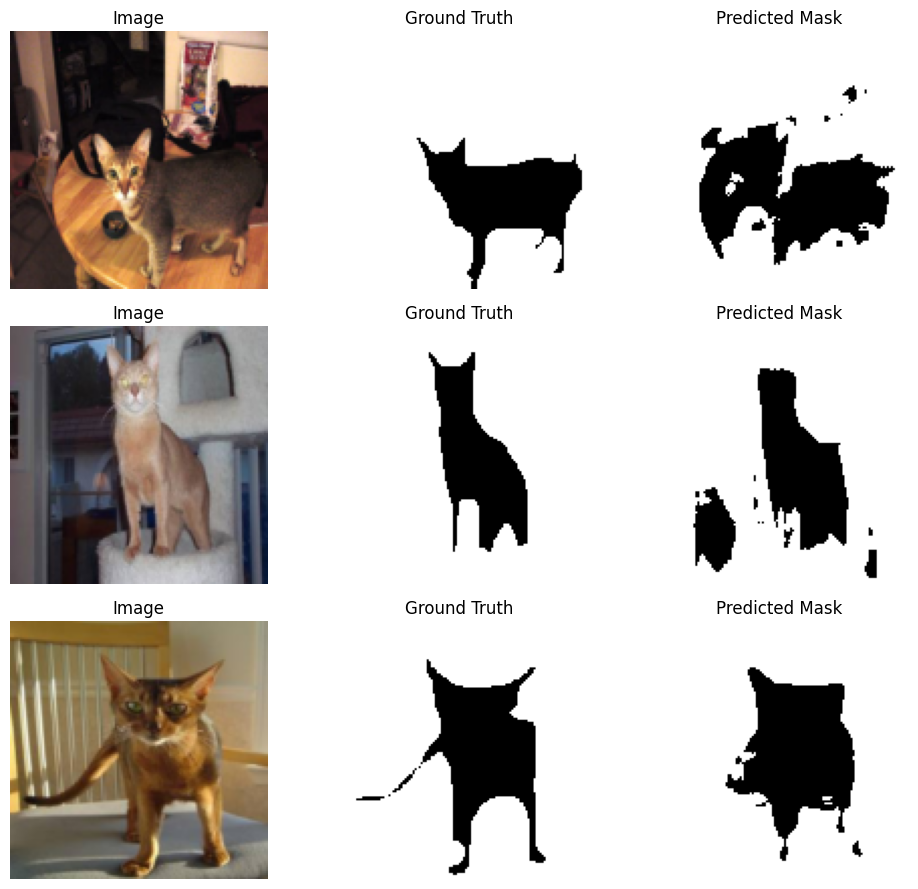

In [11]:
trainer.inference_and_plot_samples(n_samples=3)

In [12]:
def plot_history(history, title="Training history"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_loss"], marker='o', label="train_loss")
    plt.plot(epochs, history["val_loss"], marker='o', label="val_loss")
    plt.title(f"{title}: Loss")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["val_iou"], marker='o', label="val_iou")
    plt.title(f"{title}: IoU")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_f1"], marker='o', label="val_f1")
    plt.title(f"{title}: F1")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

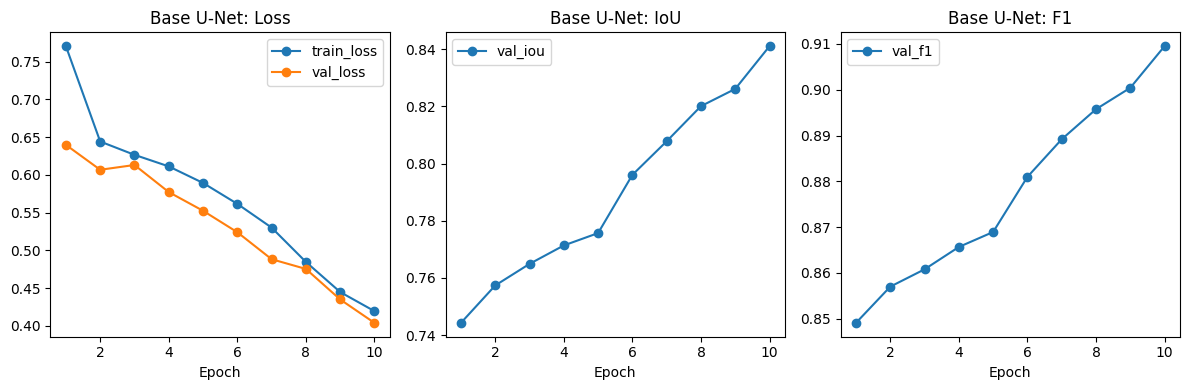

(0.4120228330078332, np.float64(0.8357209943410854), np.float64(0.9047045541789784))


In [13]:
plot_history(history_base, title="Base U-Net")
print(test_base)

In [14]:
def run_single_experiment(lr, batch_size, epochs=6, use_bn=False, features=(32, 64, 128, 256)):
    exp_config = copy.deepcopy(config)
    exp_config.learning_rate = lr
    exp_config.batch_size = batch_size
    exp_config.epochs = epochs
    exp_config.use_bn = use_bn
    exp_config.features = features

    trainer = Trainer(exp_config)
    history, test_metrics = trainer.run()

    return {
        "lr": lr,
        "batch_size": batch_size,
        "use_bn": use_bn,
        "features": features,
        "history": history,
        "test_metrics": test_metrics
    }

In [15]:
lrs = [1e-4, 1e-3, 3e-3]
batch_sizes = [8, 16, 32]

grid_results = []

for lr in lrs:
    for bs in batch_sizes:
        print("=" * 70)
        print(f"Experiment: lr={lr}, batch_size={bs}")

        result = run_single_experiment(
            lr=lr,
            batch_size=bs,
            epochs=6,
            use_bn=False,
            features=(32, 64, 128, 256)
        )

        history = result["history"]
        test_metrics = result["test_metrics"]

        grid_results.append({
            "lr": lr,
            "batch_size": bs,
            "best_val_iou": max(history["val_iou"]),
            "best_val_f1": max(history["val_f1"]),
            "final_val_loss": history["val_loss"][-1],
            "test_iou": test_metrics[1],
            "test_f1": test_metrics[2],
        })

Experiment: lr=0.0001, batch_size=8


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:10<00:00,  8.84it/s]


Epoch 1 / 6, Train Loss: 0.7846, Val Loss: 0.6914, Val IoU: 0.7357, Val F1-score: 0.8404


100%|██████████| 92/92 [00:10<00:00,  8.83it/s]


Epoch 2 / 6, Train Loss: 0.6820, Val Loss: 0.6605, Val IoU: 0.7457, Val F1-score: 0.8476


...

Epoch 5 / 6, Train Loss: 0.6825, Val Loss: 0.6580, Val IoU: 0.7484, Val F1-score: 0.8495


100%|██████████| 23/23 [00:09<00:00,  2.33it/s]


Epoch 6 / 6, Train Loss: 0.6728, Val Loss: 0.6540, Val IoU: 0.7449, Val F1-score: 0.8481
Testing...


100%|██████████| 115/115 [00:48<00:00,  2.39it/s]

Test Loss: 0.6579, Test IoU: 0.7421, Test F1-score: 0.8452


In [16]:
import pandas as pd

results_df = pd.DataFrame(grid_results)
results_df = results_df.sort_values(by="best_val_iou", ascending=False).reset_index(drop=True)
results_df

,lr,batch_size,best_val_iou,best_val_f1,final_val_loss,test_iou,test_f1
0,0.0001,8,0.828708,0.900927,0.426331,0.830606,0.901264
1,0.0010,8,0.823174,0.898592,0.435567,0.828985,0.900808
2,0.0001,16,0.796925,0.881871,0.509101,0.798810,0.881372
3,0.0010,32,0.786763,0.874236,0.549408,0.777464,0.867380
4,0.0010,16,0.760946,0.857237,0.601242,0.771043,0.863437
5,0.0001,32,0.753549,0.850910,0.619638,0.758965,0.856701
6,0.0030,32,0.748374,0.849497,0.654048,0.742116,0.845209
7,0.0030,8,0.705843,0.816913,0.728282,0.700252,0.810777
8,0.0030,16,0.696200,0.810271,0.782423,0.700088,0.810674


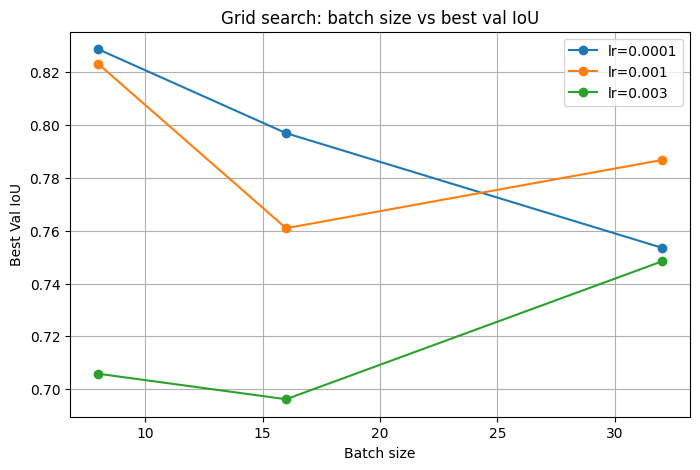

In [17]:
pivot_iou = results_df.pivot(index="batch_size", columns="lr", values="best_val_iou")

plt.figure(figsize=(8, 5))
for lr in pivot_iou.columns:
    plt.plot(pivot_iou.index, pivot_iou[lr], marker='o', label=f"lr={lr}")

plt.xlabel("Batch size")
plt.ylabel("Best Val IoU")
plt.title("Grid search: batch size vs best val IoU")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
best_row = results_df.iloc[0]
best_lr = float(best_row["lr"])
best_bs = int(best_row["batch_size"])

print("Best hyperparameters:")
print("learning_rate =", best_lr)
print("batch_size =", best_bs)

Best hyperparameters:
learning_rate = 0.0001
batch_size = 8


In [19]:
bn_result = run_single_experiment(
    lr=best_lr,
    batch_size=best_bs,
    epochs=10,
    use_bn=True,
    features=(32, 64, 128, 256)
)

history_bn = bn_result["history"]
test_bn = bn_result["test_metrics"]

print("BN model test metrics:", test_bn)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:09<00:00,  9.48it/s]


Epoch 1 / 10, Train Loss: 0.6993, Val Loss: 0.5317, Val IoU: 0.8213, Val F1-score: 0.8958


100%|██████████| 92/92 [00:10<00:00,  8.41it/s]


Epoch 2 / 10, Train Loss: 0.5012, Val Loss: 0.4894, Val IoU: 0.8314, Val F1-score: 0.9023


100%|██████████| 92/92 [00:10<00:00,  8.89it/s]


...

Epoch 9 / 10, Train Loss: 0.2331, Val Loss: 0.3091, Val IoU: 0.8752, Val F1-score: 0.9291


100%|██████████| 92/92 [00:10<00:00,  8.90it/s]


Epoch 10 / 10, Train Loss: 0.2182, Val Loss: 0.3353, Val IoU: 0.8709, Val F1-score: 0.9262
Testing...


100%|██████████| 459/459 [00:52<00:00,  8.70it/s]


Test Loss: 0.3343, Test IoU: 0.8714, Test F1-score: 0.9263
BN model test metrics: (0.3343459782160185, np.float64(0.8714015133040659), np.float64(0.926255553258425))


In [20]:
comparison_df = pd.DataFrame([
    {
        "model": "U-Net base",
        "test_loss": test_base[0],
        "test_iou": test_base[1],
        "test_f1": test_base[2]
    },
    {
        "model": "U-Net + BatchNorm",
        "test_loss": test_bn[0],
        "test_iou": test_bn[1],
        "test_f1": test_bn[2]
    }
])

comparison_df

,model,test_loss,test_iou,test_f1
0,U-Net base,0.412023,0.835721,0.904705
1,U-Net + BatchNorm,0.334346,0.871402,0.926256


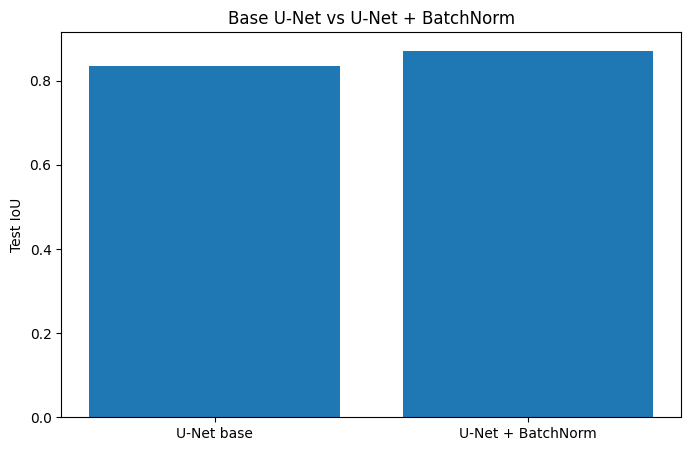

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model"], comparison_df["test_iou"])
plt.ylabel("Test IoU")
plt.title("Base U-Net vs U-Net + BatchNorm")
plt.show()

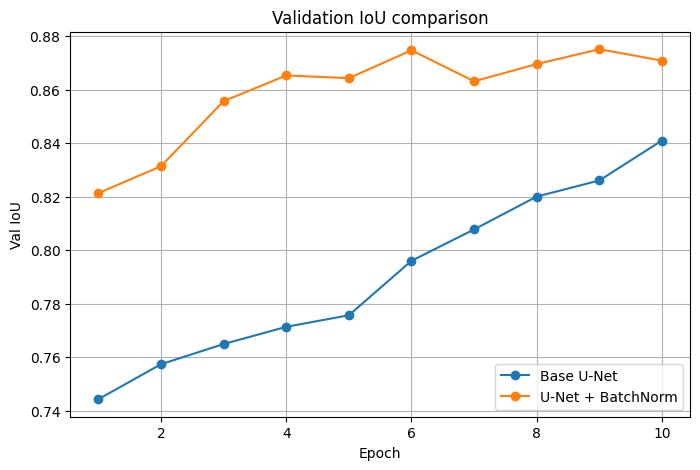

In [22]:
epochs_base = range(1, len(history_base["val_iou"]) + 1)
epochs_bn = range(1, len(history_bn["val_iou"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_base, history_base["val_iou"], marker='o', label="Base U-Net")
plt.plot(epochs_bn, history_bn["val_iou"], marker='o', label="U-Net + BatchNorm")
plt.xlabel("Epoch")
plt.ylabel("Val IoU")
plt.title("Validation IoU comparison")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
best_bn_config = copy.deepcopy(config)
best_bn_config.learning_rate = best_lr
best_bn_config.batch_size = best_bs
best_bn_config.epochs = 10
best_bn_config.use_bn = True
best_bn_config.features = (32, 64, 128, 256)

trainer_bn = Trainer(best_bn_config)
history_bn_vis, test_bn_vis = trainer_bn.run()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 92/92 [00:10<00:00,  9.20it/s]


Epoch 1 / 10, Train Loss: 0.6834, Val Loss: 0.5580, Val IoU: 0.8025, Val F1-score: 0.8851


100%|██████████| 92/92 [00:09<00:00,  9.21it/s]


Epoch 2 / 10, Train Loss: 0.4958, Val Loss: 0.4596, Val IoU: 0.8325, Val F1-score: 0.9032


100%|██████████| 92/92 [00:10<00:00,  8.88it/s]


...

Epoch 9 / 10, Train Loss: 0.2318, Val Loss: 0.3121, Val IoU: 0.8773, Val F1-score: 0.9310


100%|██████████| 92/92 [00:10<00:00,  8.93it/s]


Epoch 10 / 10, Train Loss: 0.2206, Val Loss: 0.2907, Val IoU: 0.8837, Val F1-score: 0.9350
Testing...


100%|██████████| 459/459 [00:51<00:00,  8.84it/s]

Test Loss: 0.2889, Test IoU: 0.8830, Test F1-score: 0.9337


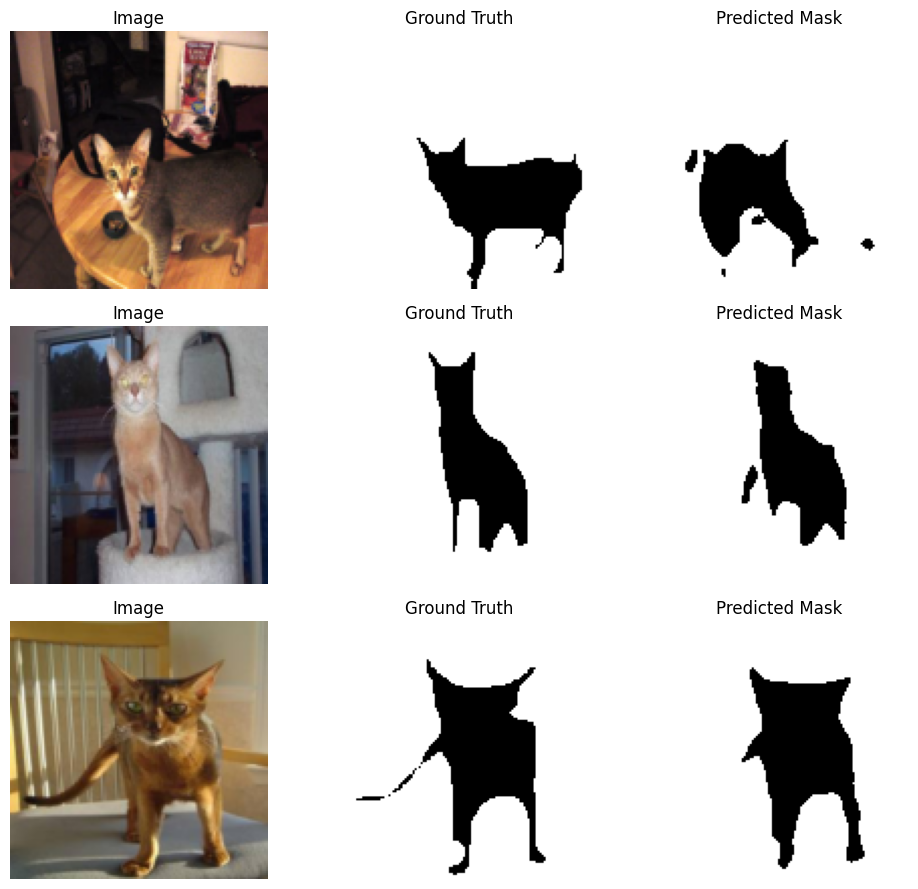

(0.2889275634275802, np.float64(0.8829995234117707), np.float64(0.9336614163159621))


In [24]:
trainer_bn.inference_and_plot_samples(n_samples=3)
print(test_bn_vis)

In [27]:
print("Выводы:")
print("1. Была обучена базовая модель U-Net на датасете Oxford-IIIT Pet")
print("2. Проведен перебор гиперпараметров learning_rate и batch_size")
print("3. Лучшая конфигурация выбиралась по метрике validation IoU")
print("4. В качестве модификации архитектуры проверен U-Net с BatchNorm")
print("5. Сравнение базовой и модифицированной модели показало влияние нормализации на качество сегментации")

Выводы:
1. Была обучена базовая модель U-Net на датасете Oxford-IIIT Pet
2. Проведен перебор гиперпараметров learning_rate и batch_size
3. Лучшая конфигурация выбиралась по метрике validation IoU
4. В качестве модификации архитектуры проверен U-Net с BatchNorm
5. Сравнение базовой и модифицированной модели показало влияние нормализации на качество сегментации
